# ShopSmart E-Commerce

# Importing Libraries & Packages

In [1]:
# Importing Python Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importing Sklearn Packages
from sklearn.preprocessing import LabelEncoder, OneHotEncoder # Data Encoding
from sklearn.preprocessing import StandardScaler # Feature Scaling
from sklearn.model_selection import train_test_split # Train-Test_split
from sklearn.compose import ColumnTransformer # Preprocessing Pipeline
from sklearn.pipeline import Pipeline # Pipeline

from sklearn.tree import DecisionTreeClassifier # Decision Tree Classifier
from sklearn.model_selection import GridSearchCV # Hyperparameter Tuning
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score # Evaluation metrics
from sklearn.metrics import ConfusionMatrixDisplay # Confusion Matrix

# Loading the Dataset

In [2]:
# Loading the Dataset
df = pd.read_csv("shop_smart_ecommerce.csv")

#### Collecting Basic Info

In [3]:
# Collecting Basic Info
df.shape
df.info()
df.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
9499,4,353.500000,0,0.0,24,583.083333,0.000000,0.007692,0.000000,0.0,Nov,1,1,1,2,Returning_Visitor,False,False
1856,5,143.833333,1,55.0,19,1762.500000,0.000000,0.013462,31.546427,0.0,Mar,3,2,1,2,Returning_Visitor,False,True
5380,0,0.000000,0,0.0,50,1156.384921,0.008000,0.035500,0.000000,0.6,May,2,2,4,1,Returning_Visitor,False,False
363,4,86.000000,0,0.0,46,2450.688095,0.027083,0.047905,0.000000,0.0,Mar,1,1,3,3,Returning_Visitor,False,False
6982,4,120.900000,0,0.0,7,534.000000,0.000000,0.029630,0.000000,0.0,Aug,2,2,7,2,Returning_Visitor,False,False


# Data Cleaning & Pre-processing

#### 1. Checking Missing Values

In [4]:
# Checking Missing Values
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_%": (df.isnull().sum()/len(df))*100
})

missing_val = missing[missing["missing_count"]>0]

print("No missing values found!") if missing_val.empty else missing_val

No missing values found!


#### 2. Checking Duplicate Values

In [5]:
# Checking Duplicate Values
duplicates = df.duplicated().sum()

if duplicates > 0:
    duplicate_rows = df[df.duplicated()]
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print("New Shape:", df.shape)
else:
    print("No duplicate found!")

New Shape: (12205, 18)


In [6]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


#### 3. Inspecting Data Inconsistency

In [7]:
# Inspecting Data Inconsistency
df.info()

# Converting bool cols to integer
df["Weekend"] = df["Weekend"].astype(int)
df["Revenue"] = df["Revenue"].astype(int)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12205 entries, 0 to 12204
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  object 
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType           

#### 4. Fixing Column names & Column data

In [8]:
# Fixing Column names & Column data
df.columns = df.columns.str.strip()

for col in df.select_dtypes(include="object"):
    df[col] = df[col].str.strip()

#### 5. Identifying Unique Values in Categrical Columns

In [9]:
# Identifying Unique Values in Categrical Columns
for col in df.select_dtypes(include="object"):
    print("Column:", col)
    print("Unique Values:", df[col].nunique())
    print(df[col].value_counts(normalize=True)*100)
    print("*"*127)

Column: Month
Unique Values: 10
Month
May     27.275707
Nov     24.432610
Mar     15.239656
Dec     13.977878
Oct      4.498156
Sep      3.670627
Aug      3.547726
Jul      3.539533
June     2.335109
Feb      1.482999
Name: proportion, dtype: float64
*******************************************************************************************************************************
Column: VisitorType
Unique Values: 3
VisitorType
Returning_Visitor    85.464973
New_Visitor          13.871364
Other                 0.663662
Name: proportion, dtype: float64
*******************************************************************************************************************************


#### 6. Getting a Summary of the dataset

In [10]:
# Getting a Summary of the dataset
df.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType,Weekend,Revenue
count,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000,12205.000000
mean,2.338878,81.646331,0.508726,34.825454,32.045637,1206.982457,0.020370,0.041466,5.949574,0.061942,2.124211,2.357804,3.153298,4.073904,0.234248,0.156329
std,3.330436,177.491845,1.275617,141.424807,44.593649,1919.601400,0.045255,0.046163,18.653671,0.199666,0.906823,1.710114,2.402340,4.016654,0.423545,0.363182
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,8.000000,193.000000,0.000000,0.014231,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000,0.000000,0.000000
50%,1.000000,9.000000,0.000000,0.000000,18.000000,608.942857,0.002899,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000,0.000000,0.000000
75%,4.000000,94.700000,0.000000,0.000000,38.000000,1477.154762,0.016667,0.048529,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000,0.000000,0.000000
max,27.000000,3398.750000,24.000000,2549.375000,705.000000,63973.522230,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000,1.000000,1.000000


# Feature Engineering

#### 1. Data Encoding

# Manual Way
#Data Encoding

#One Hot Encoding for Categorical Columns

categorical_cols = df.select_dtypes(include="object").columns

ohe = OneHotEncoder(

    drop = "first", # Avoid Dummy Variable Trap)
    
    sparse_output = False, # Get both zero & non-zero values
    
    handle_unknown = "ignore" # Encodes unknown data in testing dataset, which was not seen in training dataset
    
)

encoded = ohe.fit_transform(df[categorical_cols])

encoded_df = pd.DataFrame(encoded, columns = ohe.get_feature_names_out(categorical_cols), index = df.index)

df = pd.concat([df.drop(columns=categorical_cols), encoded_df], axis=1)


#Label Encoding for Bool Columns

le = LabelEncoder()

df["Weekend"] = le.fit_transform(df["Weekend"])

#### 2. Feature Scaling

# Manual Way
#Feature Scaling

scaler = StandardScaler()

num_cols = df.select_dtypes(include=["int64", "float64"]).columns

df[num_cols] = scaler.fit_transform(df[num_cols])

# Train Test Split

In [11]:
# Train Test Split
X = df.drop("Revenue", axis=1)
y = df["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend
5221,0,0.000000,0,0.00,6,132.000000,0.000000,0.033333,0.000000,0.0,May,4,1,3,5,New_Visitor,0
9592,0,0.000000,0,0.00,87,1197.700198,0.000000,0.002353,38.000639,0.0,Nov,2,2,1,2,New_Visitor,0
10977,7,194.083333,1,71.25,15,446.250000,0.000000,0.015686,0.000000,0.0,Dec,2,2,1,2,Returning_Visitor,0
7428,7,236.400000,0,0.00,14,341.700000,0.059649,0.084211,0.000000,0.0,June,3,2,4,3,Returning_Visitor,0
6632,0,0.000000,0,0.00,7,1721.666667,0.038095,0.038571,0.000000,0.0,Nov,1,1,3,3,Returning_Visitor,0


# Preprocessing Pipeline

In [12]:
# Preprocessng Pipeline
num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object", "category"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

# Decision Tree Classifier

***Model Training***

# Manual Way
#Decision Tree Classifier

#Model Training

dt = DecisionTreeClassifier(

    max_depth=6, # prevents deep overfitting
    
    min_samples_leaf=30, # smoothes out decision boundaries
    
    class_weight="balanced", # handles imbalance
    
    random_state=42
    
)

dt.fit(X_train,y_train)

y_pred = dt.predict(X_test)

In [13]:
dt = DecisionTreeClassifier(
    max_depth=6,              # prevents deep overfitting
    min_samples_leaf=30,      # smooths decision boundaries
    class_weight="balanced",  # handles imbalance
    random_state=42
)

pipe = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        
        ("model", dt)
    ]
)

pipe.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


***Model Evaluation***

In [14]:
# Model Evaluation
y_pred = pipe.predict(X_test)

print("Accuracy:", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1 Score:", f1_score(y_test,y_pred))

Accuracy: 0.8455551003687014
Precision: 0.4873524451939292
Recall: 0.7983425414364641
F1 Score: 0.6052356020942409


#### Hyperparameter Tuning

# Manual Way
#Hyperparameter Tuning

param_grid = {

    "max_depth": [4,6,8],
    
    "min_samples_split": [2,5,10],
    
    "min_samples_leaf": [20,30,50],
    
    "ccp_alpha": [0.0, 0.001, 0.005]
    
}

ClassifierCV = GridSearchCV(

    estimator = dt,
    
    param_grid = param_grid,
    
    scoring = "f1",
    
    cv = 5,
    
    n_jobs = -1
    
)

ClassifierCV.fit(X_train,y_train)

y_pred = ClassifierCV.predict(X_test)

print("Accuracy:", accuracy_score(y_test,y_pred))

print("Precision:", precision_score(y_test,y_pred))

print("Recall:", recall_score(y_test,y_pred))

print("F1 Score:", f1_score(y_test,y_pred))

print("Best Params:", ClassifierCV.best_params_)

print("Best F1 Score:", ClassifierCV.best_score_)

In [15]:
param_grid = {
    "model__max_depth": [4, 6, 8],
    "model__min_samples_leaf": [20, 30, 50],
    "model__min_samples_split": [2,5,10],
    "model__ccp_alpha": [0.0, 0.001, 0.005]
}

grid = GridSearchCV(
    estimator = pipe,
    param_grid = param_grid,
    scoring = "f1",
    cv = 5,
    n_jobs = -1
)

grid.fit(X_train, y_train)

print("Best F1:", grid.best_score_)
print("Best params:", grid.best_params_)

Best F1: 0.6542645940131082
Best params: {'model__ccp_alpha': 0.0, 'model__max_depth': 4, 'model__min_samples_leaf': 50, 'model__min_samples_split': 2}


#### Confusion Matrix

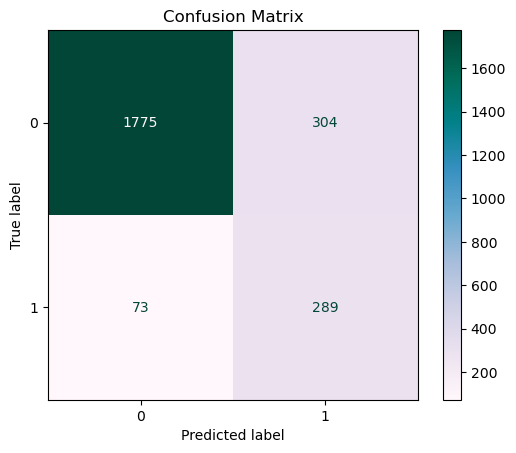

In [16]:
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="PuBuGn")
plt.title("Confusion Matrix")
plt.show()